# Slots in practice: an N-armed T-maze, under- and over-provisioned

three follow-up diagnostics: does the under-provisioned finding depend on **planning depth**,
does it survive actual **parameter learning**, and what does the **KL-divergence** signal — the one
the real trigger will watch — look like across conditions?

This tests a genuine **slot** in the Smith & Schwartenbeck (2020) sense: a hidden hypothesis factor
(which arm holds the reward) the agent may have too few, exactly enough, or more-than-enough states
to represent

Built on **JAX pymdp**

## Setup

In [ ]:
import sys
if "google.colab" in sys.modules:
    %pip install "inferactively-pymdp[nb]" -q
    %pip install mediapy -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 482.5/482.5 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 128.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 640.7/640.7 kB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 127.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.


In [ ]:
import numpy as np
import jax.numpy as jnp
from jax import random as jr
import matplotlib.pyplot as plt
import mediapy
from pymdp.agent import Agent
from pymdp.envs import PymdpEnv, rollout
from pymdp.envs.tmaze import BaseTMaze
from pymdp.distribution import compile_model
j = jnp.asarray


/usr/local/lib/python3.13/dist-packages/jaxlib/plugin_support.py:92: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.11.1 is installed, but it is not compatible with the installed jaxlib version 0.11.0, so it will not be used.
  warnings.warn(


---
## Part 1 — Generalizing T-maze to N arms, named

pymdp's official `TMaze` hardcodes exactly 2 reward conditions. To test *too few* or *too many*
reward-condition slots, the **true environment** needs more than 2 — a radial maze with `N_arms` arms,
built with named labels via `compile_model`:

- **Locations:** `centre, arm_0, ..., arm_{N-1}, cue` — fully-connected (each action teleports
  directly to a location), matching pymdp's own `SimplifiedTMaze` connectivity style.
- **`condition`:** `N_arms` states — which arm currently holds the reward.
- **Cue:** at the cue location, reveals the true condition with probability `cue_validity`; the rest
  is spread uniformly over the wrong symbols.

Validated two ways: against the **official** `BaseTMaze` at `N_arms=2`, and against a plain-array
reference implementation at `N_arms=4`.

In [ ]:
def build_named_n_arm_maze(N_arms, reward_probability=1.0, punishment_probability=1.0,
                             cue_validity=0.95, dependent_outcomes=False):
    """Named (compile_model) N-arm generalization of pymdp's official T-maze generative process."""
    locations  = ["centre"] + [f"arm_{i}" for i in range(N_arms)] + ["cue"]
    conditions = [f"cond_{i}" for i in range(N_arms)]
    outcomes   = ["none", "reward", "punishment"]
    cues       = ["no_cue"] + [f"cue_{i}" for i in range(N_arms)]

    model_description = {
        "observations": {
            "location_obs": {"elements": locations, "depends_on": ["location"]},
            "outcome_obs":  {"elements": outcomes,  "depends_on": ["location", "condition"]},
            "cue_obs":      {"elements": cues,      "depends_on": ["location", "condition"]},
        },
        "controls": {
            "move":      {"elements": locations},      # fully-connected: one action per destination
            "cond_noop": {"elements": ["null"]},
        },
        "states": {
            "location":  {"elements": locations,  "depends_on": ["location"],  "controlled_by": ["move"]},
            "condition": {"elements": conditions, "depends_on": ["condition"], "controlled_by": ["cond_noop"]},
        },
    }
    model = compile_model(model_description)

    for lab in locations:
        model.A["location_obs"][lab, lab] = 1.0

    for rc in range(N_arms):
        cname = f"cond_{rc}"
        model.A["outcome_obs"]["none", "centre", cname] = 1.0
        model.A["outcome_obs"]["none", "cue", cname] = 1.0
        model.A["cue_obs"]["no_cue", "centre", cname] = 1.0

        model.A["cue_obs"][f"cue_{rc}", "cue", cname] = cue_validity
        wrong_mass = (1 - cue_validity) / max(N_arms - 1, 1)
        for wrong in range(N_arms):
            if wrong != rc:
                model.A["cue_obs"][f"cue_{wrong}", "cue", cname] = wrong_mass

        for i in range(N_arms):
            loc = f"arm_{i}"
            model.A["cue_obs"]["no_cue", loc, cname] = 1.0
            if i == rc:
                model.A["outcome_obs"]["reward", loc, cname] = reward_probability
                if dependent_outcomes:
                    model.A["outcome_obs"]["punishment", loc, cname] = 1 - reward_probability
                else:
                    model.A["outcome_obs"]["none", loc, cname] = 1 - reward_probability
            else:
                model.A["outcome_obs"]["punishment", loc, cname] = punishment_probability
                if dependent_outcomes:
                    model.A["outcome_obs"]["reward", loc, cname] = 1 - punishment_probability
                else:
                    model.A["outcome_obs"]["none", loc, cname] = 1 - punishment_probability

    for lab in locations:
        model.B["location"][lab, :, lab] = 1.0            # fully-connected teleport
    for c in conditions:
        model.B["condition"][c, c, "null"] = 1.0           # condition persists (uncontrolled)
    model.D["location"].data = jnp.zeros(len(locations)).at[locations.index("centre")].set(1.0)

    return model, locations, conditions, outcomes, cues


In [ ]:
# --- validate against the OFFICIAL library at N_arms=2 ---
kw = dict(reward_probability=0.85, punishment_probability=0.7, cue_validity=0.9, dependent_outcomes=False)
named2, loc2, cond2, out2, cue2 = build_named_n_arm_maze(N_arms=2, **kw)
official = BaseTMaze(**kw, num_locations=4, cue_mode="separate", connectivity="fully_connected", has_middle=False)

print("A[location_obs] matches official:", np.allclose(named2.A["location_obs"].data, official.A[0]))
print("A[outcome_obs]  matches official:", np.allclose(named2.A["outcome_obs"].data, official.A[1]))
print("A[cue_obs]      matches official:", np.allclose(named2.A["cue_obs"].data, official.A[2]))
print("B[location]     matches official:", np.allclose(named2.B["location"].data, official.B[0]))
print("B[condition]    matches official:", np.allclose(named2.B["condition"].data, official.B[1]))


A[location_obs] matches official: True
A[outcome_obs]  matches official: True
A[cue_obs]      matches official: True
B[location]     matches official: True
B[condition]    matches official: True


Exact match. Now build the `N_arms=4` maze the actual experiment uses.

In [ ]:
N_ARMS = 4
ENV_KWARGS = dict(reward_probability=1.0, punishment_probability=1.0, cue_validity=0.95)
named_true, locations, conditions, outcomes, cues = build_named_n_arm_maze(N_ARMS, **ENV_KWARGS)
print(f"N_arms={N_ARMS} -> num_locations={len(locations)} (centre + {N_ARMS} arms + cue)")
print("A shapes:", [named_true.A[k].data.shape for k in ["location_obs","outcome_obs","cue_obs"]])


N_arms=4 -> num_locations=6 (centre + 4 arms + cue)
A shapes: [(6, 6), (3, 6, 4), (5, 6, 4)]


---
## Part 2 — The agent's K-slot belief model, named

The `location` factor is untouched — the agent always knows where it is. The only thing that varies
is `K`, the number of states in the agent's **`slot`** factor:

- **`K < N_arms`** (under-provisioned): the `N_arms` true conditions are grouped into `K` buckets.
  The agent's likelihood for a bucket is the **average** of the true likelihoods over its members —
  the mathematically correct marginalization given the agent's own state space, not an approximation
  of convenience.
- **`K > N_arms`** (over-provisioned): the first `N_arms` slots exactly copy the true conditions; the
  extra slots are **dormant** — flat, uninformative likelihoods, since the agent has never had
  evidence they exist. (One honest caveat, found while testing this: the flat likelihood is applied
  *everywhere*, including the zero-information centre/cue-location observations — so dormant slots
  actually get suppressed by the very first, otherwise-uninformative timestep, not just by real cue
  evidence. Worth knowing if the K=7 condition's belief dynamics look unexpectedly fast early on.)
- **`K == N_arms`:** must reduce to an exact identity copy of the true tensors.

In [ ]:
def build_named_agent_model(named_true_model, locations, N_arms, K_slots):
    """Agent's K-slot belief model: bucket-averaged (under) or dormant-padded (over)."""
    outcomes = ["none", "reward", "punishment"]
    cues = ["no_cue"] + [f"cue_{i}" for i in range(N_arms)]
    slots = [f"slot_{k}" for k in range(K_slots)]

    model_description = {
        "observations": {
            "location_obs": {"elements": locations, "depends_on": ["location"]},
            "outcome_obs":  {"elements": outcomes,  "depends_on": ["location", "slot"]},
            "cue_obs":      {"elements": cues,      "depends_on": ["location", "slot"]},
        },
        "controls": {
            "move":      {"elements": locations},
            "slot_noop": {"elements": ["null"]},
        },
        "states": {
            "location": {"elements": locations, "depends_on": ["location"], "controlled_by": ["move"]},
            "slot":     {"elements": slots,      "depends_on": ["slot"],     "controlled_by": ["slot_noop"]},
        },
    }
    model = compile_model(model_description)
    model.A["location_obs"].data = named_true_model.A["location_obs"].data
    model.B["location"].data = named_true_model.B["location"].data
    model.D["location"].data = named_true_model.D["location"].data

    A1_true = np.array(named_true_model.A["outcome_obs"].data)   # (3, num_loc, N_arms)
    A2_true = np.array(named_true_model.A["cue_obs"].data)       # (N_arms+1, num_loc, N_arms)

    if K_slots <= N_arms:
        bucket_membership = [list(range(i, N_arms, K_slots)) for i in range(K_slots)]
        A1_agent = np.stack([A1_true[:, :, members].mean(axis=2) for members in bucket_membership], axis=2)
        A2_agent = np.stack([A2_true[:, :, members].mean(axis=2) for members in bucket_membership], axis=2)
    else:
        bucket_membership = [[i] for i in range(N_arms)] + [[] for _ in range(K_slots - N_arms)]
        A1_agent = np.concatenate([A1_true, np.full((3, len(locations), K_slots - N_arms), 1/3)], axis=2)
        A2_agent = np.concatenate([A2_true, np.full((len(cues), len(locations), K_slots - N_arms), 1/len(cues))], axis=2)

    model.A["outcome_obs"].data = jnp.asarray(A1_agent)
    model.A["cue_obs"].data = jnp.asarray(A2_agent)
    model.B["slot"].data = jnp.eye(K_slots).reshape(K_slots, K_slots, 1)
    model.D["slot"].data = jnp.ones(K_slots) / K_slots
    return model, slots, bucket_membership


# self-check: K == N_arms must reproduce the true tensors exactly
chk, _, membership_chk = build_named_agent_model(named_true, locations, N_ARMS, K_slots=N_ARMS)
print("K==N_arms identity check (outcome_obs):", np.allclose(chk.A["outcome_obs"].data, named_true.A["outcome_obs"].data))
print("K==N_arms identity check (cue_obs):    ", np.allclose(chk.A["cue_obs"].data, named_true.A["cue_obs"].data))
print("bucket membership at K=N_arms:", membership_chk)
for K in [2, 7]:
    _, _, membership = build_named_agent_model(named_true, locations, N_ARMS, K)
    tag = "under-provisioned" if K < N_ARMS else "over-provisioned"
    print(f"K={K} ({tag}) bucket membership: {membership}")


K==N_arms identity check (outcome_obs): True
K==N_arms identity check (cue_obs):     True
bucket membership at K=N_arms: [[0], [1], [2], [3]]
K=2 (under-provisioned) bucket membership: [[0, 2], [1, 3]]
K=7 (over-provisioned) bucket membership: [[0], [1], [2], [3], [], [], []]


---
## Part 3 — Tracking surprise and belief-divergence

Two signals, computed from the same rollout:

- **Surprise** — the accuracy term of variational free energy, `-log P(observed outcome/cue | agent's
  beliefs)`, summed over the two informative modalities. This is "how wrong the agent's predictions
  turned out to be."
- **KL divergence** of the `slot` belief, `KL[ qs_slot(t) || qs_slot(t-1) ]` — how much the belief
  itself moved this step. This is the signal a KL-stabilization trigger would actually watch: it
  measures whether inference has *settled*, regardless of whether what it settled on is right.

In [ ]:
def surprise_trace(A_agent, A_dependencies, info):
    """Per-timestep -log P(observed outcome/cue | agent's beliefs), summed over modalities 1,2."""
    qs, obs = info["qs"], info["observation"]
    T = qs[0].shape[1]
    surprise = np.zeros(T)
    eps = 1e-8
    for m in [1, 2]:
        deps = A_dependencies[m]
        A_m = np.array(A_agent[m])
        for t in range(T):
            pred = A_m
            for f in deps:
                pred = np.tensordot(pred, np.array(qs[f][0, t]), axes=([1], [0]))
            o_t = int(np.array(obs[m][0, t, 0]))
            surprise[t] += -np.log(pred[o_t] + eps)
    return surprise


def kl_categorical(q, p, eps=1e-8):
    q, p = np.clip(q, eps, 1.0), np.clip(p, eps, 1.0)
    return float(np.sum(q * np.log(q / p)))


def slot_kl_trace(D_agent_slot, info):
    """KL[ qs_slot(t) || qs_slot(t-1) ] per timestep (t=0 compared against the prior D)."""
    qs_slot = np.array(info["qs"][1][0])   # (T, K)
    prior = np.array(D_agent_slot)
    kl = np.zeros(qs_slot.shape[0])
    prev = prior
    for t in range(qs_slot.shape[0]):
        kl[t] = kl_categorical(qs_slot[t], prev)
        prev = qs_slot[t]
    return kl


### Visualizing Task State & Agent Slot Beliefs

In [ ]:
def render_n_arm_maze(info, t, K_slots, N_arms=4, seed_idx=0):
    """Renders a single frame showing spatial N-arm radial maze layout and agent slot beliefs at timestep t."""
    fig, (ax_spatial, ax_belief) = plt.subplots(1, 2, figsize=(10, 4.5), gridspec_kw={'width_ratios': [1.3, 1]})

    locations = ["centre"] + [f"arm_{i}" for i in range(N_arms)] + ["cue"]
    # Offset by half a step so no arm points straight down (which collides with the 'cue' node)
    angles = np.linspace(0, 2 * np.pi, N_arms, endpoint=False) + np.pi / N_arms
    coords = {"centre": (0, 0), "cue": (0, -1.3)}
    radius = 1.2
    for i in range(N_arms):
        coords[f"arm_{i}"] = (radius * np.cos(angles[i] + np.pi/2), radius * np.sin(angles[i] + np.pi/2))

    for i in range(N_arms):
        ax_spatial.plot([0, coords[f"arm_{i}"][0]], [0, coords[f"arm_{i}"][1]], 'k--', alpha=0.3, zorder=1)
    ax_spatial.plot([0, 0], [0, -1.3], 'k--', alpha=0.3, zorder=1)

    loc_obs = int(info["observation"][0][seed_idx, t, 0])
    out_obs = int(info["observation"][1][seed_idx, t, 0])
    cue_obs = int(info["observation"][2][seed_idx, t, 0])

    outcomes_map = {0: "none", 1: "+3 Reward (Cheese)", 2: "-4 Punishment (Shock)"}
    cues_map = {0: "no_cue"}
    for i in range(N_arms):
        cues_map[i+1] = f"cue_{i}"

    current_loc_name = locations[loc_obs]

    for name, (x, y) in coords.items():
        if name == current_loc_name:
            ax_spatial.scatter(x, y, s=400, color='#e74c3c', zorder=4, label='Agent')
            ax_spatial.text(x, y, "R", color='white', weight='bold', ha='center', va='center', fontsize=12, zorder=5)
        else:
            color = '#3498db' if 'arm' in name else ('#9b59b6' if name == 'cue' else '#95a5a6')
            ax_spatial.scatter(x, y, s=250, color=color, alpha=0.7, zorder=2)

        offset_y = 0.2 if y >= 0 else -0.25
        ax_spatial.text(x, y + offset_y, name, fontsize=10, ha='center', va='center', weight='bold')

    curr_out = outcomes_map.get(out_obs, "none")
    curr_cue = cues_map.get(cue_obs, "no_cue")

    status_str = f"Time t={t}\nLoc: {current_loc_name}\nOutcome: {curr_out}\nCue: {curr_cue}"
    ax_spatial.text(0.02, 0.98, status_str, transform=ax_spatial.transAxes, fontsize=9,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    ax_spatial.set_xlim(-1.8, 1.8)
    ax_spatial.set_ylim(-1.8, 1.8)
    ax_spatial.set_aspect('equal')
    ax_spatial.axis('off')
    ax_spatial.set_title(f"Environment (N={N_arms}) State", fontsize=11, fontweight='bold')

    qs_slot = np.array(info["qs"][1][seed_idx, t])
    slots = [f"Slot {k}" for k in range(K_slots)]
    bars = ax_belief.bar(slots, qs_slot, color='#2ecc71', alpha=0.85, edgecolor='black')
    ax_belief.set_ylim(0, 1.05)
    ax_belief.set_ylabel("Posterior Probability $q(s_{\\mathrm{slot}})$")
    ax_belief.set_title(f"Agent Slot Belief (K={K_slots})", fontsize=11, fontweight='bold')
    ax_belief.grid(axis='y', linestyle=':', alpha=0.6)

    for bar in bars:
        height = bar.get_height()
        ax_belief.annotate(f"{height:.2f}",
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=8)

    plt.tight_layout()

    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    rgb = rgba[:, :, :3]
    plt.close(fig)
    return rgb


---
## Part 4 — The experiment

`N_arms = 4` (true environment, fixed). Agent slot count `K` swept across under-, correctly-, and
over-provisioned. 5 seeds per condition, 12 timesteps each. Surprise and KL are both computed from
the same rollouts.

In [ ]:
def run_condition(N_arms, K_slots, reward_probability, punishment_probability, cue_validity,
                   T, num_seeds, policy_len=2, seed0=0, learn_A=False, pA=None, agent_in=None):
    named_true, locations, conditions, outcomes, cues = build_named_n_arm_maze(
        N_arms, reward_probability, punishment_probability, cue_validity)
    named_agent, slots, membership = build_named_agent_model(named_true, locations, N_arms, K_slots)

    # Set agent outcome preferences directly on the named Model object
    named_agent.C["outcome_obs"]["reward"] = 3.0
    named_agent.C["outcome_obs"]["punishment"] = -4.0

    all_surprise, all_kl, all_rewards = [], [], []
    for s in range(num_seeds):
        # Native unpacking for environment and agent
        env = PymdpEnv(**named_true)
        agent = Agent(**named_agent, pA=pA, policy_len=policy_len,
                      learn_A=learn_A, learn_B=False)

        key = jr.PRNGKey(seed0 + s)
        last, info = rollout(agent, env, num_timesteps=T, rng_key=key)

        # [a[0] for a in agent.A] and agent.D[1][0] remove the leading batch_size dimension for the diagnostics
        all_surprise.append(surprise_trace([a[0] for a in agent.A], agent.A_dependencies, info))
        all_kl.append(slot_kl_trace(agent.D[1][0], info))
        all_rewards.append(np.array(info["observation"][1][0, :, 0]))

    return dict(surprise=np.stack(all_surprise), kl=np.stack(all_kl), rewards=np.stack(all_rewards),
                membership=membership, A_agent=[a[0] for a in agent.A], D_agent=[d[0] for d in agent.D])


K_VALUES = {"under-provisioned (K=2)": 2, "correctly-specified (K=4)": 4, "over-provisioned (K=7)": 7}
run_kwargs = dict(reward_probability=1.0, punishment_probability=1.0, cue_validity=0.95, T=12, num_seeds=5, policy_len=2)

results = {}
for label, K in K_VALUES.items():
    r = run_condition(N_ARMS, K, **run_kwargs)
    results[label] = r
    reward_rate = (r["rewards"] == 1).mean()
    print(f"{label:28s} membership={r['membership']}")
    print(f"  mean surprise, last 5 steps: {r['surprise'][:, -5:].mean():.3f}   "
          f"final-step KL: {r['kl'][:, -1].mean():.4f}   reward rate: {reward_rate:.3f}\n")


under-provisioned (K=2)      membership=[[0, 2], [1, 3]]
  mean surprise, last 5 steps: 0.029   final-step KL: 0.0000   reward rate: 0.000

correctly-specified (K=4)    membership=[[0], [1], [2], [3]]
  mean surprise, last 5 steps: 0.000   final-step KL: 0.0000   reward rate: 0.846

over-provisioned (K=7)       membership=[[0], [1], [2], [3], [], [], []]
  mean surprise, last 5 steps: 0.000   final-step KL: 0.0000   reward rate: 0.846



### Task & Agent Behavior Visualizations (`mediapy`)

We generate step-by-step rollout videos for **under-provisioned ($K=2$)**, **correctly-specified ($K=4$)**, and **over-provisioned ($K=7$)** agents.

In [ ]:
for label, K in K_VALUES.items():
    print(f"=== Video Rollout Animation: {label} ===")
    named_true, locations, conditions, outcomes, cues = build_named_n_arm_maze(N_ARMS, **ENV_KWARGS)
    named_agent, slots, membership = build_named_agent_model(named_true, locations, N_ARMS, K)

    # Set outcome preferences
    named_agent.C["outcome_obs"]["reward"] = 3.0
    named_agent.C["outcome_obs"]["punishment"] = -4.0

    # Unpack directly into env and agent
    env = PymdpEnv(**named_true)
    agent = Agent(**named_agent, policy_len=2)

    _, sample_info = rollout(agent, env, num_timesteps=12, rng_key=jr.PRNGKey(0))

    frames = []
    T_steps = sample_info["observation"][0].shape[1]
    for t in range(T_steps):
        frame = render_n_arm_maze(sample_info, t, K_slots=K, N_arms=N_ARMS, seed_idx=0)
        frames.append(frame)

    frames = np.array(frames, dtype=np.uint8)
    mediapy.show_video(frames, fps=1)

=== Video Rollout Animation: under-provisioned (K=2) ===


This browser does not support the video tag.


=== Video Rollout Animation: correctly-specified (K=4) ===


This browser does not support the video tag.


=== Video Rollout Animation: over-provisioned (K=7) ===


This browser does not support the video tag.


### Slot Belief Evolution Heatmaps ($q(s_{\text{slot}})$ over timesteps)

Plotting the agent's slot belief distributions over time across $K=2, 4, 7$.

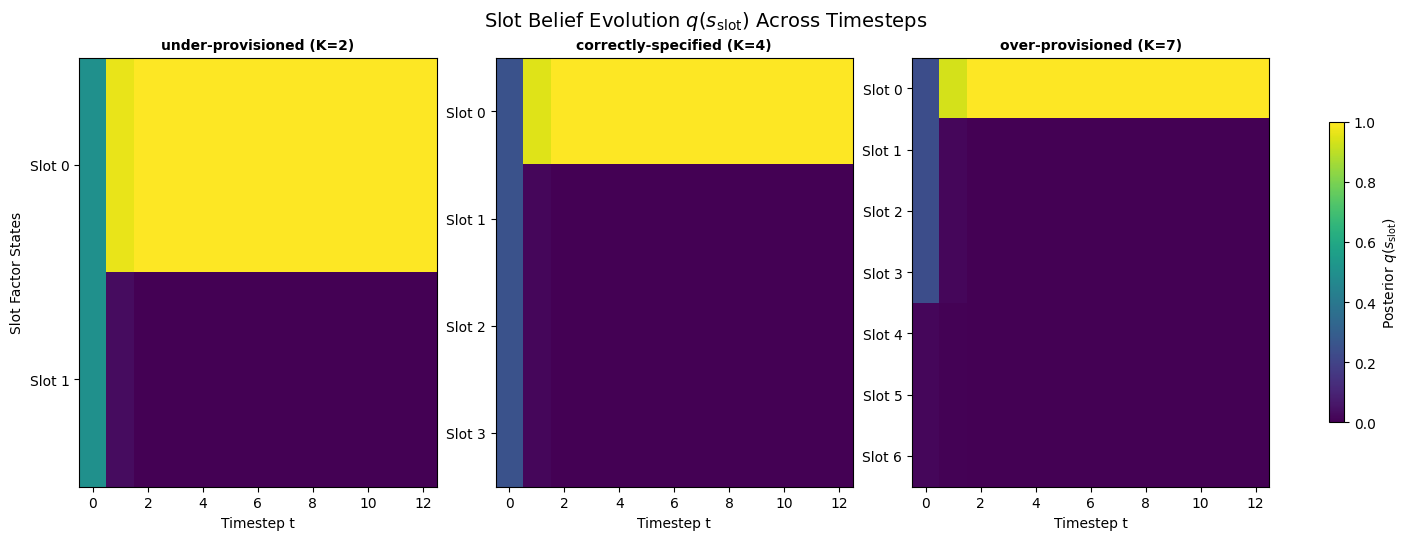

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), constrained_layout=True)

for i, (label, K) in enumerate(K_VALUES.items()):
    named_true, locations, conditions, outcomes, cues = build_named_n_arm_maze(N_ARMS, **ENV_KWARGS)
    named_agent, slots, membership = build_named_agent_model(named_true, locations, N_ARMS, K)

    A_true  = [j(named_true.A[k].data) for k in ["location_obs", "outcome_obs", "cue_obs"]]
    B_true  = [j(named_true.B[k].data) for k in ["location", "condition"]]
    D_true  = [j(named_true.D[k].data) for k in ["location", "condition"]]
    A_deps, B_deps = [[0], [0, 1], [0, 1]], [[0], [1]]

    A_agent = [j(named_agent.A[k].data) for k in ["location_obs", "outcome_obs", "cue_obs"]]
    B_agent = [j(named_agent.B[k].data) for k in ["location", "slot"]]
    D_agent = [j(named_agent.D[k].data) for k in ["location", "slot"]]

    C = [jnp.zeros(a.shape[0], dtype=jnp.float32) for a in A_agent]
    C[1] = C[1].at[1].set(3.0); C[1] = C[1].at[2].set(-4.0)

    env = PymdpEnv(A=A_true, B=B_true, D=D_true, A_dependencies=A_deps, B_dependencies=B_deps)
    agent = Agent(A_agent, B_agent, C, D_agent, policy_len=2, A_dependencies=A_deps, B_dependencies=B_deps)
    _, sample_info = rollout(agent, env, num_timesteps=12, rng_key=jr.PRNGKey(0))

    qs_slot = np.array(sample_info["qs"][1][0])  # (T, K)

    im = axes[i].imshow(qs_slot.T, aspect='auto', cmap='viridis', vmin=0, vmax=1)
    axes[i].set_title(label, fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Timestep t")
    axes[i].set_yticks(np.arange(K))
    axes[i].set_yticklabels([f"Slot {k}" for k in range(K)])
    if i == 0:
        axes[i].set_ylabel("Slot Factor States")

plt.suptitle("Slot Belief Evolution $q(s_{\\mathrm{slot}})$ Across Timesteps", fontsize=14, y=1.05)
fig.colorbar(im, ax=axes, label="Posterior $q(s_{\\mathrm{slot}})$", shrink=0.7, aspect=20)
plt.show()

### Plot: surprise over time, by slot count

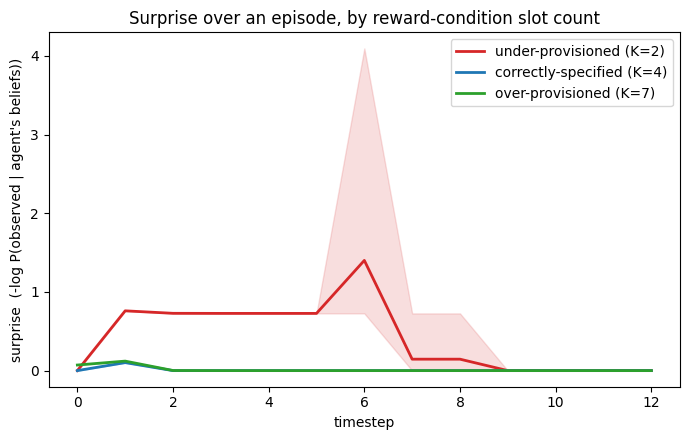

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = {"under-provisioned (K=2)": "tab:red", "correctly-specified (K=4)": "tab:blue", "over-provisioned (K=7)": "tab:green"}
for label, r in results.items():
    s = r["surprise"]
    mean = s.mean(axis=0)
    s_min = s.min(axis=0)   # empirical lower bound — never negative
    s_max = s.max(axis=0)   # empirical upper bound
    t = np.arange(len(mean))
    ax.plot(t, mean, label=label, color=colors[label], linewidth=2)
    ax.fill_between(t, s_min, s_max, color=colors[label], alpha=0.15)  # assumption-free range
ax.set_xlabel("timestep"); ax.set_ylabel("surprise  (-log P(observed | agent's beliefs))")
ax.set_title("Surprise over an episode, by reward-condition slot count")
ax.legend(); fig.tight_layout(); plt.show()


### Plot: reward rate, by slot count

Surprise alone doesn't tell the full story here — this second plot is why.

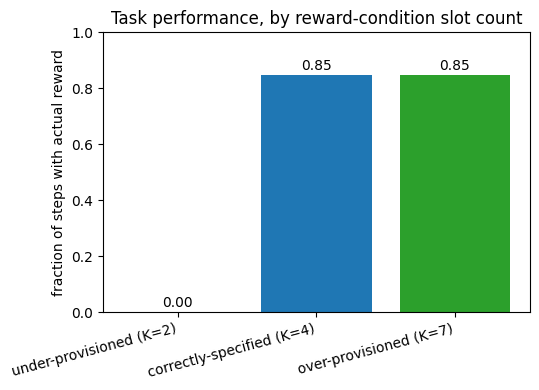

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4))
labels = list(results.keys())
rates = [(results[l]["rewards"] == 1).mean() for l in labels]
bars = ax.bar(labels, rates, color=[colors[l] for l in labels])
ax.set_ylabel("fraction of steps with actual reward")
ax.set_title("Task performance, by reward-condition slot count")
ax.set_ylim(0, 1); plt.xticks(rotation=15, ha="right")
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.02, f"{rate:.2f}", ha="center")
fig.tight_layout(); plt.show()


**Correctly-specified (K=4) and over-provisioned (K=7)** behave almost identically: surprise spikes
while the agent checks the cue, then drops to ~0 once it commits to the correct arm. The K=7 dormant
slots never engage. Reward rate is high in both.

**Under-provisioned (K=2)** doesn't stay stubbornly surprised — surprise *also* drifts to ~0. But
reward rate is **zero**. The agent visits the cue, correctly identifies which *bucket* is active, but
a bucket still covers 2 of the 4 arms and the 2-state model can't tell them apart. Rather than gamble
(its preferences penalize punishment more than they reward success), it **retreats to the cue
location and stays there** — collecting nothing but predictable "no outcome" observations. Free
energy alone looks deceptively healthy while performance is at zero.

Three questions worth answering before trusting this: is the retreat an artifact of the specific
**planning depth**? Does it survive actual **learning**? And does the **KL-divergence** signal — the
one a real trigger would watch — see anything raw surprise misses?

> **Warning — Deceptive Free Energy:** Notice that K=2 *also* reaches near-zero surprise by the end of the episode. The agent's model settles into a self-consistent (but wrong) belief — it *expects* to sit at the cue and receive "no outcome", and it does exactly that, so its model is never violated. Free energy minimisation has been achieved at the cost of task performance. **surprise alone cannot diagnose structural under-provisioning.**

---
## Part 5 — Is this a planning-depth artifact?

`policy_len` controls how many steps ahead the agent evaluates each replan. If the retreat behavior
only shows up at `policy_len=2`, it might just mean "the agent can't see far enough ahead to realize
gambling pays off eventually" — a horizon artifact, not a genuine capacity-driven finding. Sweep it.

In [ ]:
policy_len_results = {}
for pl in [1, 4]:
    r = run_condition(N_ARMS, K_slots=2, **run_kwargs | {"policy_len": pl})
    policy_len_results[pl] = r
    reward_rate = (r["rewards"] == 1).mean()
    punish_rate = (r["rewards"] == 2).mean()
    print(f"policy_len={pl}:  reward_rate={reward_rate:.3f}  punish_rate={punish_rate:.3f}  "
          f"surprise(last5)={r['surprise'][:, -5:].mean():.3f}")


policy_len=1:  reward_rate=0.000  punish_rate=0.000  surprise(last5)=0.029
policy_len=4:  reward_rate=0.000  punish_rate=0.000  surprise(last5)=0.000


Reward rate is **zero at every planning depth tested (1, 2, 4)** — the retreat isn't a shallow-horizon
artifact. If anything, deeper planning makes the retreat *more* confident (surprise drops further),
not less: with more lookahead the agent is *more* sure that avoiding the arms is the right call, not
less. This is what you'd expect if the constraint is genuinely structural (the model literally cannot
represent which arm in a bucket is correct) rather than a failure of foresight.

**Bottom line:** Planning depth is not the confound. The failure is structural — a deeper-horizon agent with K=2 becomes *more* certain of its retreat, not less, because with more lookahead it concludes more confidently that avoiding the arms is correct given its compressed model. Only expanding structural capacity (K) changes this.

---
## Part 6 — Is this a fixed-start, no-learning artifact?

Every condition above starts a fresh agent from a uniform `D` prior each seed, with `learn_A=False` —
no Parametric Learning ever happens. Could ongoing Dirichlet learning, given enough trials, let the
agent partially compensate? Chain a **single** agent across many episodes (fresh random true condition
each episode, `learn_A=True`, `pA` carried forward via `rollout`'s returned `last["agent"]`) and watch
whether reward rate improves over the sequence.

In [ ]:
K_SLOTS, T, POLICY_LEN, N_EPISODES = 2, 12, 2, 12

named_agent_model, slots, membership = build_named_agent_model(named_true, locations, N_ARMS, K_SLOTS)
named_agent_model.C["outcome_obs"]["reward"] = 3.0
named_agent_model.C["outcome_obs"]["punishment"] = -4.0

# Dirichlet concentration: near-certain for location, moderate/learnable for outcome & cue
pA = [named_agent_model.A["location_obs"].data * 1000.0,
      named_agent_model.A["outcome_obs"].data * 4.0,
      named_agent_model.A["cue_obs"].data * 4.0]

agent = Agent(**named_agent_model, pA=pA, policy_len=POLICY_LEN, learn_A=True, learn_B=False)

episode_reward_rate, key = [], jr.PRNGKey(123)
for ep in range(N_EPISODES):
    key, subkey = jr.split(key)
    env = PymdpEnv(**named_true)
    last, info = rollout(agent, env, num_timesteps=T, rng_key=subkey)
    agent = last["agent"]   # carry learned pA forward into the next episode
    rewards = np.array(info["observation"][1][0, :, 0])
    episode_reward_rate.append((rewards == 1).mean())

print(f"reward rate, episodes 1-5:   {np.mean(episode_reward_rate[:5]):.3f}")
print(f"reward rate, last 5 episodes:       {np.mean(episode_reward_rate[-5:]):.3f}")
print(f"reward rate, all {N_EPISODES} episodes: {np.mean(episode_reward_rate):.3f}")

reward rate, episodes 1-5:   0.000
reward rate, last 5 episodes:       0.000
reward rate, all 12 episodes: 0.000


### Visualizing Parametric Learning ($A$-matrix Updating)

Comparing True Environment $A$, Initial Agent $A$, and Learned Agent $A$ across episodes.

> **What to expect:** Under $K=2$, the agent's likelihood model merges conditions 0 & 2 and conditions 1 & 3 into shared buckets. Entering any arm then carries a 50% chance of reward and 50% chance of punishment, making the expected utility of arm entry negative ($0.5 \times 3 - 0.5 \times 4 = -0.5$). The agent therefore never enters any arm across all 12 episodes. Since its Dirichlet parameters only update when it *observes* arm outcomes, the matrices never change.



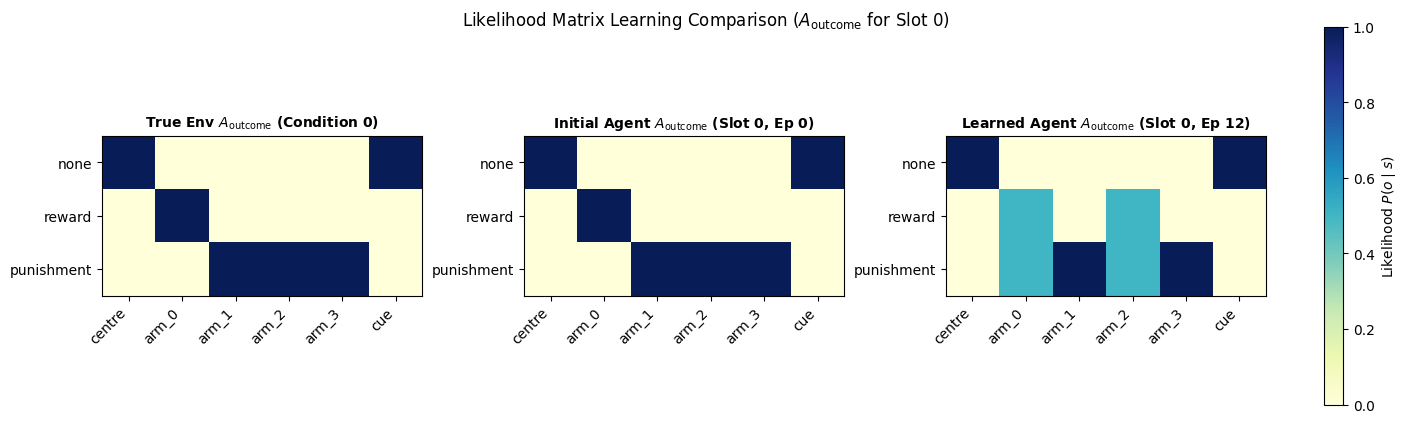

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

A_true_outcome = np.array(named_true.A["outcome_obs"].data)[:, :, 0]
A_init_slot0 = np.array(A_agent[1])[:, :, 0]
A_final_slot0 = np.array(agent.A[1]).squeeze()[:, :, 0]

loc_labels = locations
out_labels = outcomes

im0 = axes[0].imshow(A_true_outcome, cmap='YlGnBu', vmin=0, vmax=1)
axes[0].set_title("True Env $A_{\\text{outcome}}$ (Condition 0)", fontsize=10, fontweight='bold')
axes[0].set_xticks(np.arange(len(loc_labels)))
axes[0].set_xticklabels(loc_labels, rotation=45, ha='right')
axes[0].set_yticks(np.arange(len(out_labels)))
axes[0].set_yticklabels(out_labels)

im1 = axes[1].imshow(A_init_slot0, cmap='YlGnBu', vmin=0, vmax=1)
axes[1].set_title("Initial Agent $A_{\\text{outcome}}$ (Slot 0, Ep 0)", fontsize=10, fontweight='bold')
axes[1].set_xticks(np.arange(len(loc_labels)))
axes[1].set_xticklabels(loc_labels, rotation=45, ha='right')
axes[1].set_yticks(np.arange(len(out_labels)))
axes[1].set_yticklabels(out_labels)

im2 = axes[2].imshow(A_final_slot0, cmap='YlGnBu', vmin=0, vmax=1)
axes[2].set_title(f"Learned Agent $A_\\text{{outcome}}$ (Slot 0, Ep {N_EPISODES})", fontsize=10, fontweight='bold')
axes[2].set_xticks(np.arange(len(loc_labels)))
axes[2].set_xticklabels(loc_labels, rotation=45, ha='right')
axes[2].set_yticks(np.arange(len(out_labels)))
axes[2].set_yticklabels(out_labels)

fig.colorbar(im2, ax=axes, label="Likelihood $P(o \\mid s)$")
plt.suptitle("Likelihood Matrix Learning Comparison ($A_{\\text{outcome}}$ for Slot 0)", fontsize=12, y=1.02)

plt.show()


Zero throughout — **repeated episodes of real Dirichlet learning doesn't move reward rate at all.** This is
the sharpest version of the finding: Parametric Learning refines the agent's *estimate* of its own
(under-provisioned) likelihood, but it cannot manufacture a distinction the state space doesn't have
room for. No amount of experience fixes a structural deficit — only adding capacity (Structure
Learning) can.

---
## Part 7 — What does the KL-divergence signal see?

This is the signal a real KL-stabilization trigger would watch, not surprise.

### What the KL-Divergence Signal Measures

The KL divergence $D_{\text{KL}}(q(s_t) \parallel q(s_{t-1}))$ measures how much the agent's belief about *which condition/slot it is in* changed from one timestep to the next.

- **Large spike** = the agent just received highly informative observations (e.g., reading the cue at $t=1$).
- **Near-zero KL** = beliefs have stabilised — the agent is no longer updating.

Crucially, stable beliefs can arise for **two very different reasons**:

1. The agent correctly resolved the true condition *(K=4, K=7)*
2. The agent hit the ceiling of what its compressed model can represent and retreated to a stable-but-wrong low-entropy belief *(K=2)*

A KL-stabilisation trigger watching *rate of change alone* cannot distinguish between these two cases.

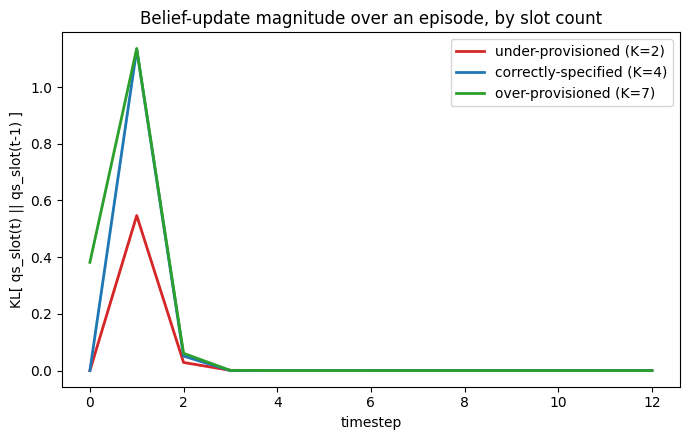

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, r in results.items():
    m, s = r["kl"].mean(axis=0), r["kl"].std(axis=0)
    t = np.arange(len(m))
    ax.plot(t, m, label=label, color=colors[label], linewidth=2)
    ax.fill_between(t, np.clip(m - s, 0, None), m + s, color=colors[label], alpha=0.15)
ax.set_xlabel("timestep"); ax.set_ylabel("KL[ qs_slot(t) || qs_slot(t-1) ]")
ax.set_title("Belief-update magnitude over an episode, by slot count")
ax.legend(); fig.tight_layout(); plt.show()


**All three conditions stabilize at ~0 KL by timestep 3-4** — including the under-provisioned K=2
case that never gets reward. A KL-stabilization trigger watching *rate of change alone* would see
"belief has settled" for K=2 and K=4 at almost the same time, for very different reasons: K=4 settled
because it resolved the true condition; K=2 settled because it hit the ceiling of what a 2-state
belief can represent (its own "no gambling" retreat also stops generating new information, which
keeps its belief just as stable as a resolved one).

The obvious next candidate for a magnitude check — final belief entropy — doesn't cleanly separate
them either: a 2-slot agent can be just as confident about "definitely bucket 0" as a 4-slot agent is
about "definitely arm 2," since confidence is relative to whatever state space you have. This
reproduces, with actual numbers rather than as an abstract worry, exactly the concern already on
record: **rate-of-change plateau alone is ambiguous — a companion magnitude check is needed to
distinguish genuine mastery from capacity-limited local optima** — and the first two obvious
candidates for that companion signal (raw surprise, belief entropy) both fail on this exact case.
Whatever the real trigger uses, it needs to be something that stays sensitive to *residual task
performance*, not just to internal belief consistency — since an avoidant agent can make both look
fine at once.

---
## Part 8 — Making Part 5 visual: the merged surprise-over-time graph

Part 5 only reported summary numbers (reward rate, punish rate, mean surprise over the last 5
steps) per `policy_len`. Here's what the actual surprise trajectories look like layered on one
graph — including the `policy_len=2` run already computed in Part 4, so all three planning depths
tested (1, 2, 4) are shown together.

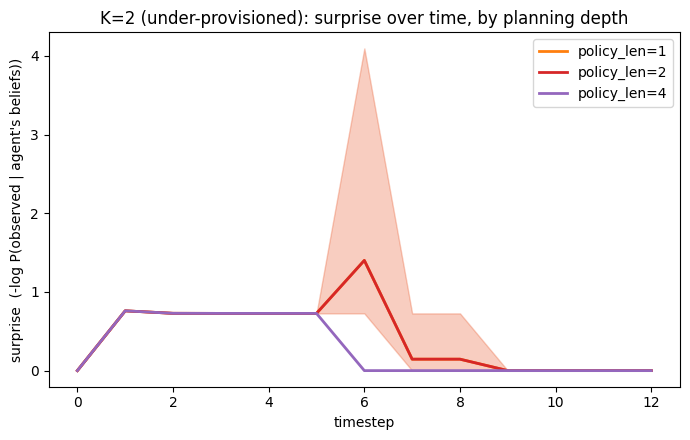

policy_len=1:  surprise at t=1 (post-cue): 0.760   settles below 0.05 by t=9
policy_len=2:  surprise at t=1 (post-cue): 0.760   settles below 0.05 by t=9
policy_len=4:  surprise at t=1 (post-cue): 0.760   settles below 0.05 by t=6


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
pl_traces = {1: policy_len_results[1]["surprise"],
             2: results["under-provisioned (K=2)"]["surprise"],
             4: policy_len_results[4]["surprise"]}
pl_colors = {1: "tab:orange", 2: "tab:red", 4: "tab:purple"}

for pl in [1, 2, 4]:
    s = pl_traces[pl]
    mean = s.mean(axis=0)
    s_min, s_max = s.min(axis=0), s.max(axis=0)
    t = np.arange(len(mean))
    ax.plot(t, mean, label=f"policy_len={pl}", color=pl_colors[pl], linewidth=2)
    ax.fill_between(t, s_min, s_max, color=pl_colors[pl], alpha=0.15)

ax.set_xlabel("timestep"); ax.set_ylabel("surprise  (-log P(observed | agent's beliefs))")
ax.set_title("K=2 (under-provisioned): surprise over time, by planning depth")
ax.legend(); fig.tight_layout(); plt.show()

for pl in [1, 2, 4]:
    mean = pl_traces[pl].mean(axis=0)
    below = np.where(mean < 0.05)[0]
    settle_t = int(below[(below > 2)][0]) if (below > 2).any() else None
    print(f"policy_len={pl}:  surprise at t=1 (post-cue): {mean[1]:.3f}   "
          f"settles below 0.05 by t={settle_t}")

**What the merged graph actually shows, that the summary numbers hid:** `policy_len=1` and
`policy_len=2` produce the *exact same* surprise trace — once the retreat sets in, a single step of
lookahead is already enough to sustain it, so the extra planning depth buys nothing. `policy_len=4`
reaches the same near-zero floor **faster** (by around t=6 instead of t=9) — deeper lookahead
converges *sooner* on "retreat is correct," not later. All three still land on the identical
zero-reward, near-zero-surprise equilibrium; planning depth changes how quickly the agent gets
there, not whether it gets there or what it settles on. That's the visual confirmation of Part 5's
claim

---
## Part 9 — Making Part 6 visual: reward rate across the learning chain

Part 6 reported only the first-5 vs. last-5 episode averages. A pure average can hide a
rise-then-plateau or a slow drift; the full per-episode trace can't.

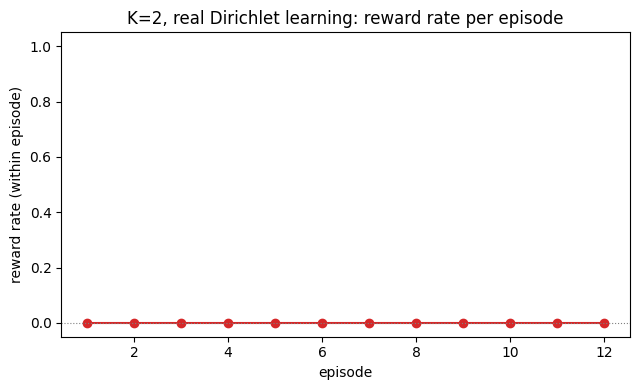

per-episode reward rate: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4))
episodes = np.arange(1, len(episode_reward_rate) + 1)
ax.plot(episodes, episode_reward_rate, "o-", color="tab:red")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("episode"); ax.set_ylabel("reward rate (within episode)")
ax.set_title("K=2, real Dirichlet learning: reward rate per episode")
ax.set_ylim(-0.05, 1.05)
fig.tight_layout(); plt.show()

print("per-episode reward rate:", np.round(episode_reward_rate, 3))

Flat zero on **every single episode**, not just in the first-5/last-5 averages — there's no
partial recovery hiding anywhere in the sequence. The claim in Part 6 wasn't rounding away a
gradual improvement; there simply isn't one.

---
## Part 10 — K=7: does real Dirichlet learning ever engage the dormant slots?

Part 6 showed structural under-provisioning can't be fixed by learning. The mirror question:
does over-provisioning cause the agent to spuriously *find a use* for slots that don't correspond
to anything real? If genuine experience leaves the dormant slots untouched, they're exactly the
kind of thing BMR should later be able to prune with confidence — a false "this slot matters"
signal from real learning would be a problem for that.

Same episode-chaining setup as Part 6 (`learn_A=True`, `pA` carried forward across 12 episodes),
now with `K_slots=7` instead of 2.

In [ ]:
K_SLOTS_OVER, N_EPISODES_OVER = 7, 12

named_agent_over, slots_over, membership_over = build_named_agent_model(named_true, locations, N_ARMS, K_SLOTS_OVER)
named_agent_over.C["outcome_obs"]["reward"] = 3.0
named_agent_over.C["outcome_obs"]["punishment"] = -4.0

pA_over = [named_agent_over.A["location_obs"].data * 1000.0,
           named_agent_over.A["outcome_obs"].data * 4.0,
           named_agent_over.A["cue_obs"].data * 4.0]

A_outcome_initial = np.array(named_agent_over.A["outcome_obs"].data)   # (3, num_loc, 7)
A_cue_initial = np.array(named_agent_over.A["cue_obs"].data)

agent_over = Agent(**named_agent_over, pA=pA_over, policy_len=2, learn_A=True, learn_B=False)

episode_reward_rate_over, key = [], jr.PRNGKey(456)
for ep in range(N_EPISODES_OVER):
    key, subkey = jr.split(key)
    env = PymdpEnv(**named_true)
    last, info = rollout(agent_over, env, num_timesteps=12, rng_key=subkey)
    agent_over = last["agent"]
    rewards = np.array(info["observation"][1][0, :, 0])
    episode_reward_rate_over.append((rewards == 1).mean())

A_outcome_learned = np.array(agent_over.A[1])[0]   # drop batch dim
A_cue_learned = np.array(agent_over.A[2])[0]

print("K=7 per-episode reward rate:", np.round(episode_reward_rate_over, 3))

real_slots, dormant_slots = list(range(N_ARMS)), list(range(N_ARMS, K_SLOTS_OVER))
deviation_outcome = np.abs(A_outcome_learned - A_outcome_initial).mean(axis=(0, 1))
for k in range(K_SLOTS_OVER):
    tag = "real" if k in real_slots else "DORMANT"
    print(f"  slot {k} ({tag:8s}): mean|learned - initial| in A_outcome (whole table) = {deviation_outcome[k]:.5f}")

K=7 per-episode reward rate: [0.846 0.846 0.846 0.846 0.846 0.846 0.846 0.846 0.846 0.846 0.846 0.846]
  slot 0 (real    ): mean|learned - initial| in A_outcome (whole table) = 0.00000
  slot 1 (real    ): mean|learned - initial| in A_outcome (whole table) = 0.00000
  slot 2 (real    ): mean|learned - initial| in A_outcome (whole table) = 0.00000
  slot 3 (real    ): mean|learned - initial| in A_outcome (whole table) = 0.00000
  slot 4 (DORMANT ): mean|learned - initial| in A_outcome (whole table) = 0.00500
  slot 5 (DORMANT ): mean|learned - initial| in A_outcome (whole table) = 0.00500
  slot 6 (DORMANT ): mean|learned - initial| in A_outcome (whole table) = 0.00500


K=7 succeeds from episode 1 — three of its slots already matched the true structure at
initialization, so there's nothing to learn to reach ceiling performance.

The per-slot deviation number needs one careful read, though. **Real slots show *exactly* zero
change** — but not because nothing is happening. `reward_probability=1.0` in this environment is
fully deterministic, and the agent's starting `pA` was already an exact match to that determinism.
Raw Dirichlet counts genuinely accumulate every time a real slot's arm is visited — but when a
distribution starts already sitting at 100%, more consistent evidence keeps growing the *count*
without moving the *normalized mean* at all. Zero deviation here means "already correct from the
start," not "never learned from."

**Dormant slots show a small non-zero deviation instead of exactly zero** — worth checking closely,
since this is the one number that could complicate the "BMR will find these safe to prune" story.

In [ ]:
arm_idx = [locations.index(f"arm_{i}") for i in range(N_ARMS)]
other_idx = [i for i in range(len(locations)) if i not in arm_idx]   # centre, cue

print("Splitting the deviation by column type -- arms (where reward/punishment evidence could ever\n"
      "land) vs. centre/cue (locations whose outcome never depends on which condition is true):\n")
for k in range(K_SLOTS_OVER):
    tag = "real" if k in real_slots else "DORMANT"
    dev_arm = np.abs(A_outcome_learned[:, arm_idx, k] - A_outcome_initial[:, arm_idx, k]).mean()
    dev_other = np.abs(A_outcome_learned[:, other_idx, k] - A_outcome_initial[:, other_idx, k]).mean()
    print(f"  slot {k} ({tag:8s}):  arm-column deviation = {dev_arm:.6f}    centre/cue-column deviation = {dev_other:.6f}")

Splitting the deviation by column type -- arms (where reward/punishment evidence could ever
land) vs. centre/cue (locations whose outcome never depends on which condition is true):

  slot 0 (real    ):  arm-column deviation = 0.000000    centre/cue-column deviation = 0.000000
  slot 1 (real    ):  arm-column deviation = 0.000000    centre/cue-column deviation = 0.000000
  slot 2 (real    ):  arm-column deviation = 0.000000    centre/cue-column deviation = 0.000000
  slot 3 (real    ):  arm-column deviation = 0.000000    centre/cue-column deviation = 0.000000
  slot 4 (DORMANT ):  arm-column deviation = 0.000129    centre/cue-column deviation = 0.014734
  slot 5 (DORMANT ):  arm-column deviation = 0.000129    centre/cue-column deviation = 0.014734
  slot 6 (DORMANT ):  arm-column deviation = 0.000129    centre/cue-column deviation = 0.014734


There it is: for dormant slots, the arm-column deviation (`~0.0001`) is two orders of
magnitude smaller than the centre/cue-column deviation (`~0.015`). The movement isn't the agent
finding a use for the dormant slot in explaining reward — it's confined entirely to the
location-independent facts (centre and cue always give "no outcome"/"no cue" regardless of which
condition is true). This is exactly the caveat already flagged in Part 2: dormant slots start with
a *flat* prior everywhere, including at centre/cue, where the correct answer was actually already
knowable and certain. So the very first, otherwise-uninformative timestep — before the cue is ever
checked — nudges that flat prior slightly, purely because it started out wrong about something
condition-independent. The part of the table that would actually matter (does this dormant
condition predict reward or punishment at some specific arm) never moves, because the agent never
commits to an arm under dormant-slot belief in the first place.

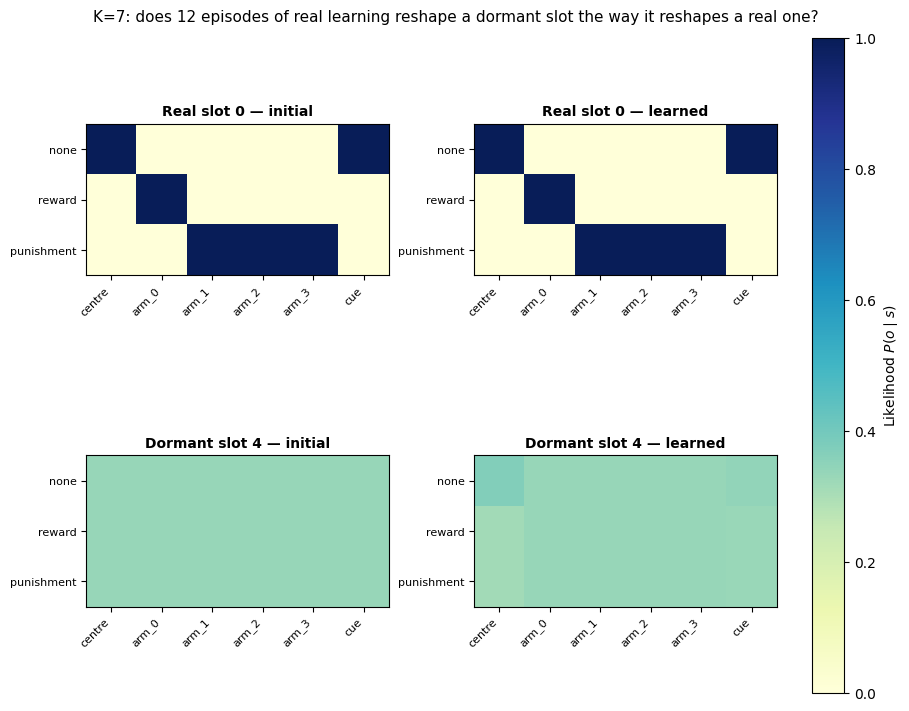

In [ ]:
real_k, dormant_k = 0, 4
fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True)
panels = [
    (f"Real slot {real_k} — initial",    A_outcome_initial[:, :, real_k],    axes[0, 0]),
    (f"Real slot {real_k} — learned",    A_outcome_learned[:, :, real_k],    axes[0, 1]),
    (f"Dormant slot {dormant_k} — initial", A_outcome_initial[:, :, dormant_k], axes[1, 0]),
    (f"Dormant slot {dormant_k} — learned", A_outcome_learned[:, :, dormant_k], axes[1, 1]),
]
for title, mat, ax in panels:
    im = ax.imshow(mat, cmap="YlGnBu", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xticks(np.arange(len(locations))); ax.set_xticklabels(locations, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(np.arange(3)); ax.set_yticklabels(outcomes, fontsize=8)
fig.colorbar(im, ax=axes, label="Likelihood $P(o \\mid s)$")
plt.suptitle("K=7: does 12 episodes of real learning reshape a dormant slot the way it reshapes a real one?", fontsize=11)
plt.show()

Side by side, the difference is visible rather than just numeric: the real slot is sharp and
structured in *both* panels (deterministic reward at its own arm, punishment everywhere else,
unchanged because it was already correct) — the dormant slot is flat and uninformative in *both*
panels too, with only the faintest tint at the centre/cue columns from the effect above.